In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')

In [74]:
path = 'processed_data\daily_average_all.csv'
data = pd.read_csv(path)
data.head()

,Unnamed: 0,index,date,pm,location,temp,dew_point,humidity,pressure,wind_speed,wind_direction,precipitation
0,0,0,2023-01-01,104.875000,DN,23.5,16.9,68,1015.4,7.1,1,0.0
1,0,0,2023-01-01,79.625000,BN,23.7,16.1,65,1015.3,6.7,45,0.0
2,0,0,2023-01-01,79.375000,KPS,22.9,16.1,68,1015.6,7.2,19,0.0
3,1,1,2023-01-02,90.583333,DN,24.0,17.4,69,1015.7,6.4,9,0.0
4,1,1,2023-01-02,89.500000,BN,24.2,17.9,69,1015.6,5.3,40,0.0


In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3288 non-null   datetime64[ns]
 1   pm             3288 non-null   float64       
 2   location       3288 non-null   object        
 3   temp           3288 non-null   float64       
 4   dew_point      3288 non-null   float64       
 5   humidity       3288 non-null   int64         
 6   pressure       3288 non-null   float64       
 7   wind_speed     3288 non-null   float64       
 8   precipitation  3288 non-null   float64       
 9   wind_dir_sin   3288 non-null   float64       
 10  wind_dir_cos   3288 non-null   float64       
 11  month          3288 non-null   int32         
 12  month_sin      3288 non-null   float64       
 13  month_cos      3288 non-null   float64       
dtypes: datetime64[ns](1), float64(10), int32(1), int64(1), object(1)
memory 

In [89]:
data.describe()

,date,pm,temp,dew_point,humidity,pressure,wind_speed,precipitation,wind_dir_sin,wind_dir_cos,month,month_sin,month_cos
count,3288,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3.288000e+03,3.288000e+03
mean,2024-07-01 12:00:00,70.350568,28.470833,23.001064,74.161800,1009.166332,5.982178,3.305870,-0.057041,-0.245444,6.521898,-4.586021e-03,-1.914303e-03
min,2023-01-01 00:00:00,6.416667,20.600000,10.300000,49.000000,1002.400000,2.100000,0.000000,-1.000000,-1.000000,1.000000,-1.000000e+00,-1.000000e+00
25%,2023-10-01 18:00:00,47.656250,27.600000,22.300000,69.000000,1007.100000,4.800000,0.000000,-0.601815,-0.920505,4.000000,-8.660254e-01,-8.660254e-01
50%,2024-07-01 12:00:00,64.895833,28.600000,23.900000,74.000000,1009.000000,5.800000,0.400000,-0.052336,-0.601815,7.000000,-2.449294e-16,-1.836970e-16
75%,2025-04-01 06:00:00,83.958333,29.700000,24.800000,79.000000,1011.100000,7.000000,4.000000,0.406737,0.615661,10.000000,5.000000e-01,8.660254e-01
max,2025-12-31 00:00:00,366.791667,33.700000,26.800000,93.000000,1018.300000,13.100000,46.400000,1.000000,1.000000,12.000000,1.000000e+00,1.000000e+00
std,NaN,34.747182,1.932626,2.607443,7.348882,2.787438,1.684197,5.906335,0.595392,0.763084,3.449511,7.059077e-01,7.085011e-01


In [75]:
df_dn = data[data['location']=='DN'] 
df_dn.head()

,Unnamed: 0,index,date,pm,location,temp,dew_point,humidity,pressure,wind_speed,wind_direction,precipitation
0,0,0,2023-01-01,104.875000,DN,23.5,16.9,68,1015.4,7.1,1,0.0
3,1,1,2023-01-02,90.583333,DN,24.0,17.4,69,1015.7,6.4,9,0.0
6,2,2,2023-01-03,115.958333,DN,25.0,19.1,71,1015.1,5.9,355,0.0
9,3,3,2023-01-04,83.875000,DN,26.7,18.8,63,1014.3,7.3,8,0.0
12,4,4,2023-01-05,84.125000,DN,26.0,19.2,68,1013.9,6.6,13,0.0


In [76]:
df_dn.columns

Index(['Unnamed: 0', 'index', 'date', 'pm', 'location', 'temp', 'dew_point',
       'humidity', 'pressure', 'wind_speed', 'wind_direction',
       'precipitation'],
      dtype='object')

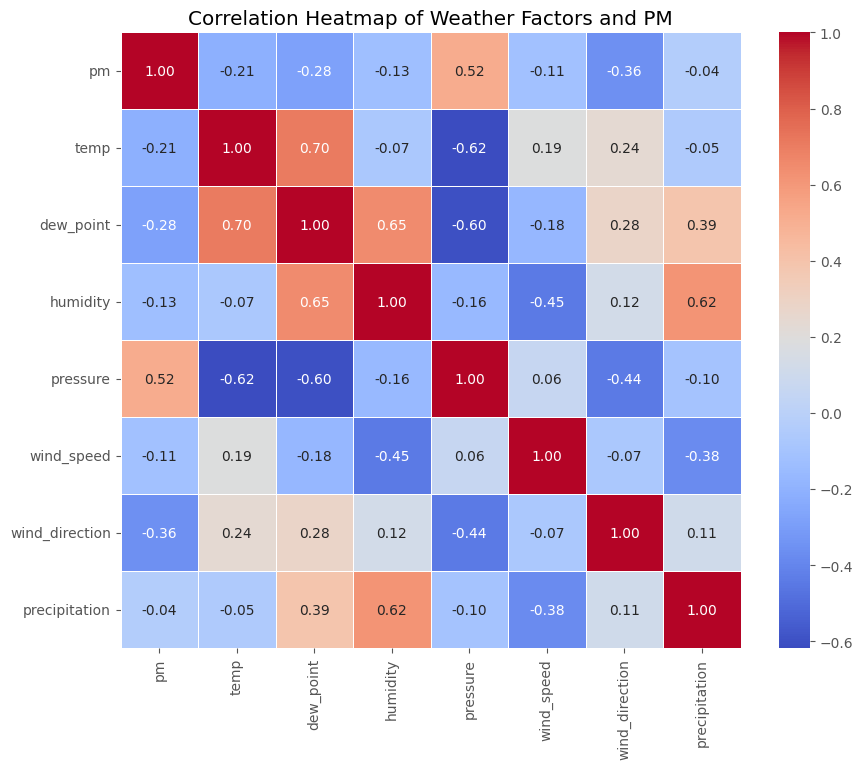

In [77]:
columns = ['pm','temp', 'dew_point',
       'humidity', 'pressure', 'wind_speed', 'wind_direction',
       'precipitation']
correlation_matrix = df_dn[columns].corr()
target = 'pm'
features = columns.copy()
features.remove(target)


# 3. แสดงผลด้วย Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Weather Factors and PM')
plt.show()

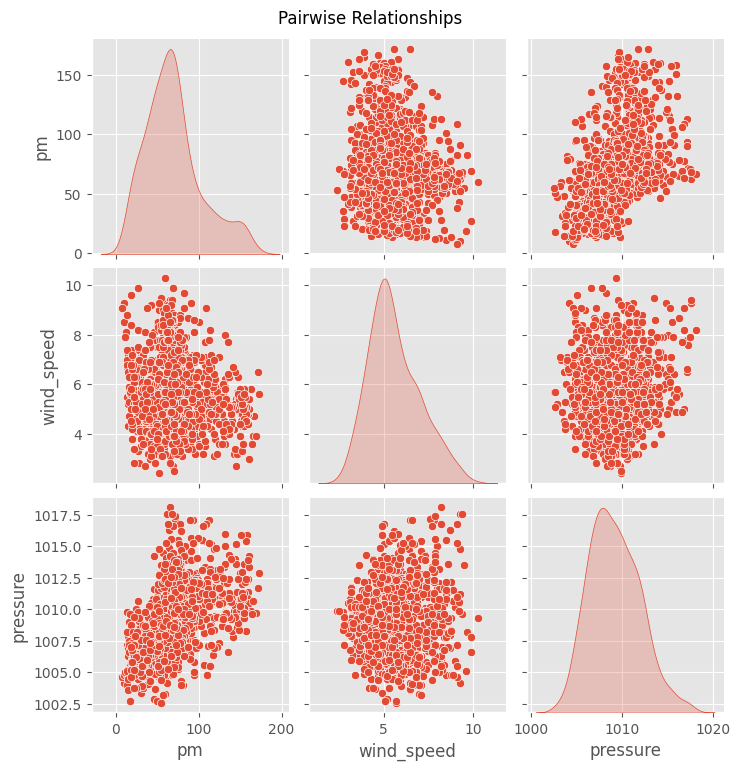

In [78]:
# เลือกเฉพาะคอลัมน์ที่น่าสนใจเพื่อไม่ให้กราฟรกเกินไป
cols_to_plot = ['pm','wind_speed', 'pressure']

# สร้าง Pair Plot
sns.pairplot(df_dn[cols_to_plot], diag_kind='kde')
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

C:\Users\kkako\AppData\Local\Temp\ipykernel_27344\3785286875.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dn['date'] = pd.to_datetime(df_dn['date'])


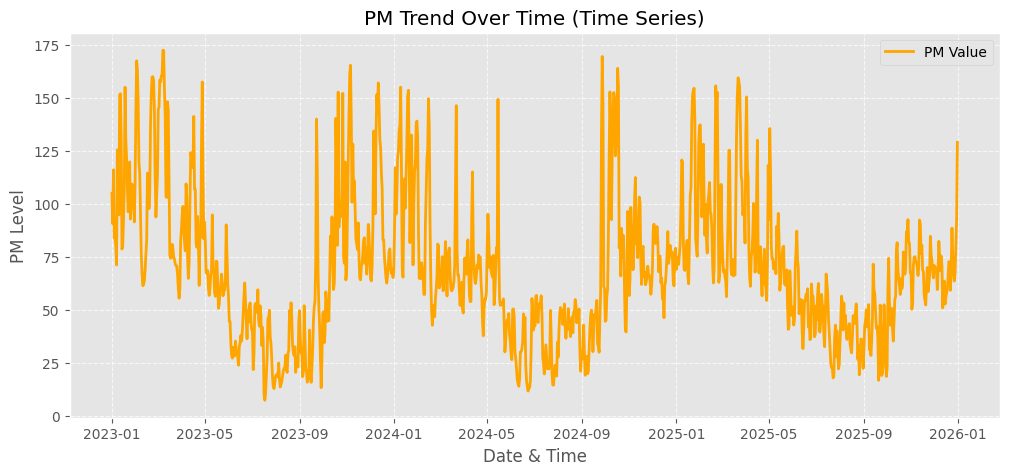

In [79]:
# --- STEP 1: Time Series ---

# แปลงเป็น datetime object (ถ้ายังไม่ได้ทำ)
df_dn['date'] = pd.to_datetime(df_dn['date'])

# พล็อตข้อมูล
plt.figure(figsize=(12, 5))
plt.plot(df_dn['date'], df_dn['pm'], color='orange', linewidth=2, label='PM Value')

# ตกแต่งกราฟ
plt.title('PM Trend Over Time (Time Series)')
plt.xlabel('Date & Time')
plt.ylabel('PM Level')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [80]:
data['wind_dir_sin'] = np.sin(2 * np.pi * data['wind_direction'] / 360)
data['wind_dir_cos'] = np.cos(2 * np.pi * data['wind_direction'] / 360)

data = data.drop(columns=['wind_direction'])

In [81]:
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month
data['month_sin'] = np.sin(2*np.pi*data['month']/12)
data['month_cos'] = np.cos(2*np.pi*data['month']/12)

In [82]:
data.drop(columns=['Unnamed: 0', 'index'], inplace=True)
data

,date,pm,location,temp,dew_point,humidity,pressure,wind_speed,precipitation,wind_dir_sin,wind_dir_cos,month,month_sin,month_cos
0,2023-01-01,104.875000,DN,23.5,16.9,68,1015.4,7.1,0.0,1.745241e-02,0.999848,1,5.000000e-01,0.866025
1,2023-01-01,79.625000,BN,23.7,16.1,65,1015.3,6.7,0.0,7.071068e-01,0.707107,1,5.000000e-01,0.866025
2,2023-01-01,79.375000,KPS,22.9,16.1,68,1015.6,7.2,0.0,3.255682e-01,0.945519,1,5.000000e-01,0.866025
3,2023-01-02,90.583333,DN,24.0,17.4,69,1015.7,6.4,0.0,1.564345e-01,0.987688,1,5.000000e-01,0.866025
4,2023-01-02,89.500000,BN,24.2,17.9,69,1015.6,5.3,0.0,6.427876e-01,0.766044,1,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3283,2025-12-30,92.166667,DN,25.6,19.2,70,1010.7,4.0,0.0,2.923717e-01,0.956305,12,-2.449294e-16,1.000000
3284,2025-12-30,75.083333,BN,27.0,18.6,62,1010.5,3.5,0.0,8.386706e-01,-0.544639,12,-2.449294e-16,1.000000
3285,2025-12-31,96.208333,BN,27.1,19.6,66,1009.1,3.2,0.0,-1.908090e-01,-0.981627,12,-2.449294e-16,1.000000
3286,2025-12-31,128.916667,DN,25.3,18.7,70,1009.2,4.1,0.0,-2.449294e-16,1.000000,12,-2.449294e-16,1.000000


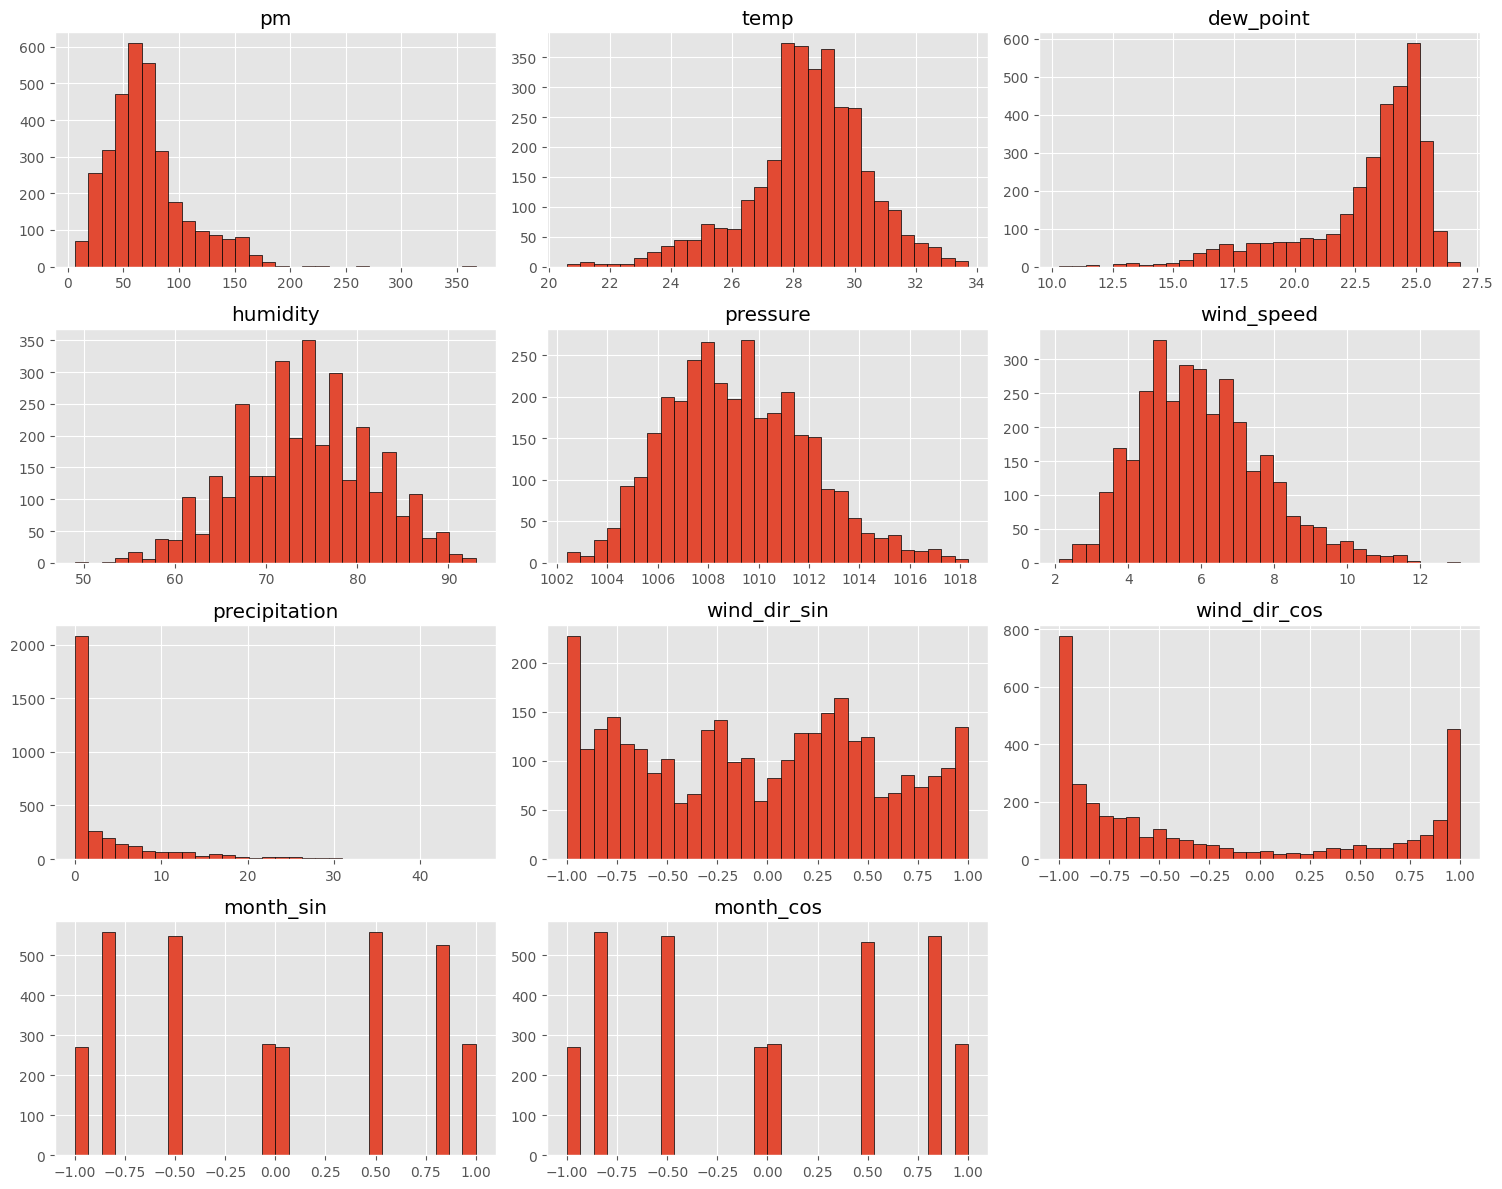

In [87]:
num_cols = data.select_dtypes(include=['float64','int64']).columns

data[num_cols].hist(
    figsize=(15,12),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

In [86]:
data.to_csv('dataset/dataset.csv', index=False)

C:\Users\kkako\AppData\Local\Temp\ipykernel_27344\3086718890.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


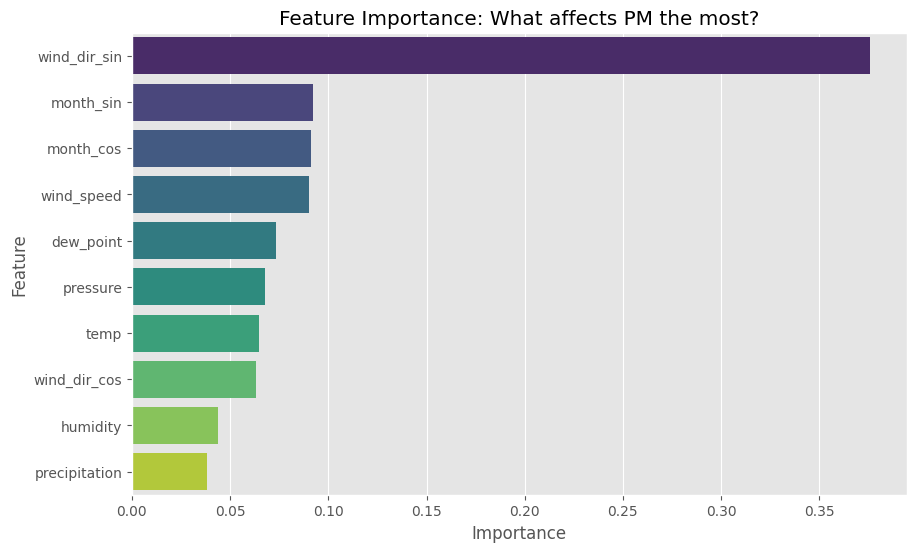

         Feature  Importance
6   wind_dir_sin    0.375799
8      month_sin    0.091960
9      month_cos    0.091198
4     wind_speed    0.089954
1      dew_point    0.073598
3       pressure    0.067924
0           temp    0.064535
7   wind_dir_cos    0.062998
2       humidity    0.044006
5  precipitation    0.038028


In [85]:
from sklearn.ensemble import RandomForestRegressor
test = data[data['location']=='DN']
# เตรียมข้อมูล (ตัด column datetime และ pm ออกรวมกับ location DN)
X = test.drop(columns=['pm', 'date', 'location', 'month']) 
y = test['pm']

# สร้างและเทรนโมเดล
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# ดึงค่าความสำคัญ
importances = rf_model.feature_importances_
feature_names = X.columns

# สร้าง Dataframe เพื่อแสดงผลและเรียงลำดับ
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# พล็อต Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importance: What affects PM the most?')
plt.show()

print(fi_df)